# A Particle in a finite well

In [1]:
#@title Import libraries
import matplotlib as mpl            # matplotlib library for plotting and visualization
import matplotlib.pylab as plt      # matplotlib library for plotting and visualization
import numpy as np                  #numpy library for numerical manipulation, especially suited for data arrays

import requests                     # HTTP library
import zipfile                       # Read and write zip files
import io

import ipywidgets as widgets
from IPython.display import display, Math, Latex

In [2]:
#@title import sympy


#import sympy
import sympy as sym
# declare sympy variables
x, y, z = sym.symbols('x y z')
h, hbar = sym.symbols('h hbar')
N_phi = sym.symbols('N_phi')
m,n = sym.symbols('m,n', integer="true", positive="true")
a, k = sym.symbols('a k', positive = "true", real = "true")
alpha, mu = sym.symbols('alpha mu', positive = "true", real = "true")
from sympy import oo

In [3]:
#@title Display Versions

import sys # checking the version of Python
import IPython # checking the version of IPython
print("Python version = {}".format(sys.version))
print("IPython version = {}".format(IPython.__version__))
#print("Matplotlib version = {}".format(plt.__version__))
print("Numpy version = {}".format(np.__version__))
#print("Matplotlib version = {}".format(plt.__version__))
print("Sympy version = {}".format(sym.__version__))


#

Python version = 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:51:49) [Clang 16.0.6 ]
IPython version = 8.26.0
Numpy version = 2.2.6
Sympy version = 1.14.0


In [4]:
#@title Check if this is a Colab instance
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Colab?", IN_COLAB)

Running in Colab? False


In [5]:
#@title Download images
!curl -O http://faculty.fairfield.edu/mkubasik/images/PIB.zip

# Now, open the zip file from disk and extract its contents
with zipfile.ZipFile("PIB.zip", 'r') as z:
    z.extractall(".")


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 262.5k 100 262.5k   0      0  1.30M      0                              0


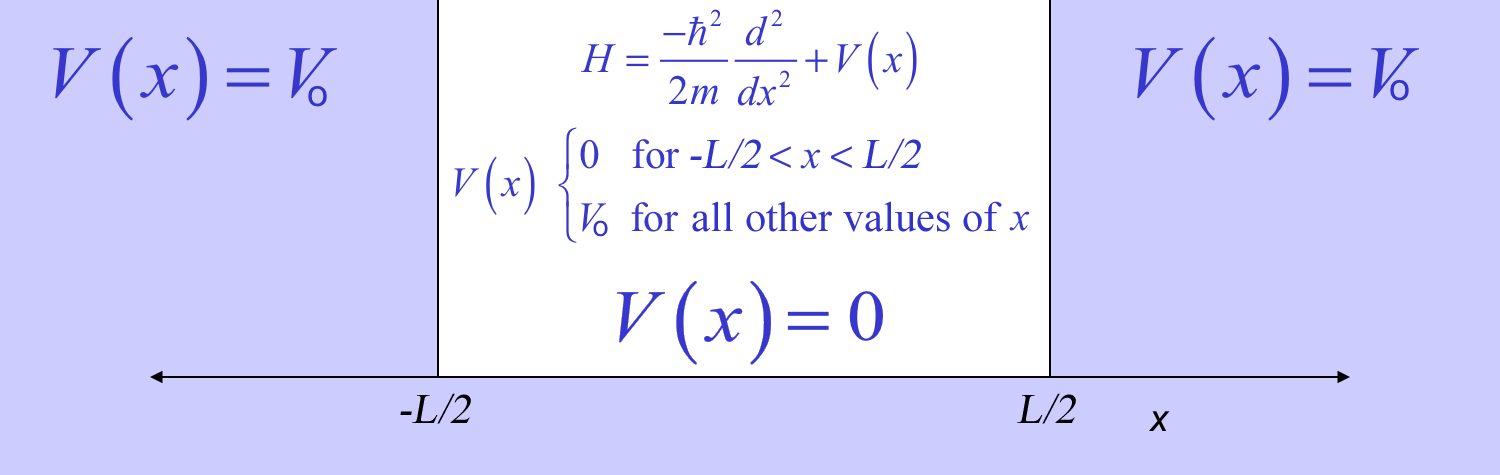

In [6]:
#@title Image of the Particle-in-a-box Potential
from IPython.display import Image
Image(filename='PIB/particle_in_a_finite_box_diagram.png', width=800, height=400)

# Notes on the well.
* The well is symmetric about x = 0
* The well has a width of $L$.
* The depth of the well is energy  $V_o$.


### $\hspace 5.0 cm$  The Schrödinger equation <br/> $\hspace 2.5 cm$  Inside the box   $\hspace 3.0 cm$ vs   $\hspace 2.5 cm$ Outside the box

$\begin{array}{ccc}
\large {\frac{d^2\psi(x)}{d x^2}} = -\frac{2mE}{\hbar^2}\psi(x) =\small {-k^2} \psi(x) &\hspace 1.5 cm &\large{\frac{d^2\psi(x)}{d x^2} = -\frac{2m(E-V_o)}{\hbar^2}\psi(x)} \\
 \mbox{Solutions have the general form of } \psi(x) = e^{\pm ikx} &\hspace 1.5 cm &
 \mbox{If } E>V_o \mbox{, the particle is unbounded and} \\
 \mbox{Therefore:} &\hspace 1.5 cm& \mbox{the particle moves freely above the walls} \\
 \psi(x) = q_1 \cos(kx) + q_2 \sin(kx) &\hspace 0.5 cm& \mbox{If } E<V_o \mbox{, the particle is bounded and} \\
  &\hspace 0.5 cm & \mbox{within the walls} \end{array} $


### $\hspace 5.0 cm$  The Schrödinger equation <br/> $\hspace 2.5 cm$  Inside the box   $\hspace 3.0 cm$ vs   $\hspace 2.5 cm$ Outside the box

$\begin{array}{ccc}
\large {\frac{d^2\psi(x)}{d x^2}} = -\frac{2mE}{\hbar^2}\psi(x) =\small {-k^2} \psi(x) &\hspace 1.5 cm &\large{\frac{d^2\psi(x)}{d x^2} = -\frac{2m(E-V_o)}{\hbar^2}\psi(x)} \\
 \mbox{Solutions have the general form of } \psi(x) = e^{\pm ikx} &\hspace 1.5 cm &
 \mbox{If } E>V_o \mbox{, the particle is unbounded and} \\
 \mbox{Therefore:} &\hspace 1.5 cm& \mbox{the particle moves freely above the walls} \\
 \psi(x) = q_1 \cos(kx) + q_2 \sin(kx) &\hspace 0.5 cm& \mbox{If } E<V_o \mbox{, the particle is bounded and} \\
  &\hspace 0.5 cm & \mbox{within the walls} \end{array} $

### The Schrödinger equation inside the box
| $$\Large{\text{Inside the box} (V = 0)}$$|
| :-------------- |
| $$\Large{\frac{d^2\psi(x)}{d x^2} = -\frac{2mE}{\hbar^2}\psi(x) = {-k^2} \psi(x)}$$ |
| Solutions have the general form of $$\Large{\psi(x) = e^{\pm ikx}}$$ $~~~~~~~~~~~~~~~~~~$|  
| Therefore: |  
| $$\Large{\psi(x) = A\cos(kx) + B\sin(kx)}$$ |






### The Schrödinger Equation outside the box

| $$\Large{\text{Outside of the box} (V = V_o, V_o > 0)}$$|
| :-------------- |
| $$\Large{\frac{d^2\psi(x)}{d x^2} = -\frac{2m(E-V_o)}{\hbar^2}\psi(x)}$$ |
| Solutions: |  
| If $E > V_o$, the particle is unbounded and moves freely above the walls. |  
| If $E < V_o$, the particle is $\textit{bound}$ and is $\textit{within}$ the walls. |


### The Schrödinger equation

| :Inside the box :| :Outside the box: |
| :------------------------------------------------------ | :------------------------------------------------------------  |
| $\large {\frac{d^2\psi(x)}{d x^2}} = -\frac{2mE}{\hbar^2}\psi(x) =\small {-k^2} \psi(x)$ | $\large{\frac{d^2\psi(x)}{d x^2} = -\frac{2m(E-V_o)}{\hbar^2}\psi(x)}$ |
| Solutions have the general form of $\psi(x) = e^{\pm ikx}$ | If $E>V_o$, the particle is unbounded and |
| Therefore: | the particle moves freely above the walls |
| $\psi(x) = q_1 \cos(kx) + q_2 \sin(kx)$ | If $E<V_o$, the particle is bounded and |
| | within the walls |



| Inside the box | Outside the box |
| :---------------: | :--------------: |
|one|two|
|three <br> four | five<br> six|



| Inside the box | Outside the box |
|:---------------:|:--------------:|
|$\large {\frac{d^2\psi(x)}{d x^2}} = -\frac{2mE}{\hbar^2}\psi(x) =\small {-k^2} \psi(x)$ <br> <br>$k^2 \equiv \frac{2mE}{\hbar^2} $ <hr><br> Solutions have the general form of <br> $\psi(x) = e^{\pm ikx}$ <br> Therefore: <br> $\psi(x) = A \cos(kx) + B \sin(kx)$ | $\frac{d^2\psi(x)}{d x^2} = -\frac{2m(E-V_o)}{\hbar^2}\psi(x) = \alpha_o^2 \psi(x)$ <br> <br>$\alpha_o^2 \equiv  \frac{2m(V_o - E)}{\hbar^2}$ <hr><br>If $V_o <E$, the particle is unbounded.<br> The particle moves freely above the walls <br> Solutions have the general form  <br>$\psi(x) = e^{\pm i\alpha_o x}$ <br> <hr>For $V_o>E$, the particle is bound  <br> to the box. <br>  $\sqrt{\alpha_o^2}$ has pure real roots.  <br> Solutions *outside the box*,  <br>when $V_o>E$  are of the form <br> $ \Psi(x) = Ce^{+\alpha_ox} + De^{-\alpha_o x}$|




|  ~~~~~~~~~~~~~~~~~~~ Inside the box ~~~~~~~~~~~~~ |       ~~~~~~~~~~~~~~~~~~~Outside the box  ~~~~~~~~~~~~~ |
|:---------------:|:--------------:|
|$\large{\frac{d^2\psi(x)}{d x^2}} = -\frac{2mE}{\hbar^2}\psi(x) =\large {-k^2 \psi(x)}$ <br> <br>$k^2 \equiv \frac{2mE}{\hbar^2} $ <hr><br> Solutions have the general form of <br> <br> $\psi_{in}(x) = e^{\pm ikx}$ <br> <br> Therefore: <br> <br> $\psi_{in}(x) = A \cos(kx) + B \sin(kx)$ | $\large{\frac{d^2\psi(x)}{d x^2} = -\frac{2m(E-V_o)}{\hbar^2}\psi(x) = \alpha_o^2 \psi(x)}$ <br> <br>$\alpha_o^2 \equiv  \frac{2m(V_o - E)}{\hbar^2}$ <hr> <br>If $V_o<E$, the particle is unbounded.<br> <br> The particle moves freely above the walls <br> Solutions have the general form  <br>$\psi_{out}(x) = e^{\pm i\alpha_o x}$ <br> <hr>For $V_o>E$, the particle is bound  <br> to the box. <br> <br>  $\sqrt{\alpha_o^2}$ has pure real roots.  <br> <br> Solutions *outside the box*,  <br>when $V_o>E$  are of the form <br> <br> $ \Psi_{out}(x) = Ce^{+\alpha_ox} + De^{-\alpha_o x}$|




For $E<V_o$, it is really interesting to look at what happens outside the walls.

When $E<V_o$, the Schrödinger equation becomes   $$\large{\frac{\partial^2\psi(x)}{\partial x^2}} = \alpha_o^2\cdot \psi(x)$$ since $\alpha_o^2 = \frac{2m(V_o-E)}{\hbar^2} >0$. The solutions to this equation have the general form of $$\large{\psi(x) =e^{\pm\alpha_o x}}$$.

Note that the exponential function doesn't require an imaginary component, thus it is not oscillatory.

Before we move on, here are some questions to consider:
* **Q1:** Can you test if this is a solution to the differential equation?  
* **Q2**  Can you write the **general solution** for a particle outside the box.  
* **Q3:** What is the value of $\alpha_o$?  
* **Q4:** Given that $\psi(x)$ must be finite, how would this constrain the solutions for $x\rightarrow -\infty$?     
* **Q5:** Given that $\psi(x)$ must be finite, how would this constrain the solutions for $x\rightarrow \infty$?  

From the general solutions, and applying those constrains, we can consider three distinct regions.  
In each region the wavefunction for $E<V_o$ will be:

$$\begin{array} {llcl}
I: & V(x) = Vo  & \hspace 0.75 cm x \leq-\frac{L}{2} & \hspace 0.75 cm\psi_{I} = A e^{\alpha_o  x} \\
II: & V(x) = 0  & \hspace 0.75 cm-\frac{L}{2} \leq x \leq\frac{L}{2} & \hspace 0.75 cm\psi_{II} = B \cos(k x) + C \sin(k x)\\
III: & V(x) =Vo  &\hspace 0.75 cm x \geq \frac{L}{2} &\hspace 0.75 cm \psi_{III} = D e^{-\alpha_o x}\end{array} $$

where:

$$\alpha_o = \frac{\sqrt{2m(V_o-E)}}{\hbar} \hspace 3cm  k = \frac{\sqrt{2mE}}{\hbar}$$

The wavefunction must obey the following **boundary conditions**:

$\large{\psi_{I}\left(-\frac{L}{2}\right) = \psi_{II}\left(-\frac{L}{2}\right)} \hspace 1cm $   and
$ \hspace 1cm \large{\psi_{II}\left(\frac{L}{2}\right) = \psi_{III}\left(\frac{L}{2}\right)}$

$\large{\psi^{'}_{I}\left(-\frac{L}{2}\right) = \psi^{'}_{II}\left(-\frac{L}{2}\right)} \hspace 1cm $   and
$ \hspace 1cm \large{\psi^{'}_{II}\left(\frac{L}{2}\right) = \psi^{'}_{III}\left(\frac{L}{2}\right)}$

where the symbol $'$ corresponds to the first derivative with respect to $x$ ($\;\psi^{'} = \frac{d\psi}{dx}$)

**Note:** $\psi^{'}$ needs to be continuous to guarantee the existence of $\psi^{''}$, whose existence is required from the first postulate.  $\large{\frac{d^2}{dx^2}}$ is a component of the kinetic energy operator. If the wavefucntion doesn't have a well-defined second derivative, then the kinetic energy would be undefined, which is not possible.

It can be shown that when the potential is even ($V(-x) = V(x)$),  the wavefunctions can be either even $[\psi(-x) = \psi(x)]$ or odd $[\psi(-x) = -\psi(x)]$.   
On the way the potential is written, we are considering that the particle is in a finite box with an even potential. Thus, even and odd solutions of the wavefucntion can be found independently:

**Even solutions:**
$$\begin{array} {ll}
\mbox{For } x \leq-\frac{L}{2}: & \psi_{I}(x) = D e^{\alpha_o  x} \\
\mbox{For } -\frac{L}{2} \leq x \leq\frac{L}{2}: & \psi_{II}(x) = B \cos(k x) \\
\mbox{For } x \geq \frac{L}{2}: & \psi_{III}(x) = D e^{-\alpha_o x}\end{array} $$
After imposing the boundary conditions we reach the following relation:
$$\alpha_o = k\tan\left(k\frac{L}{2}\right)\hspace 1cm \Rightarrow \hspace 1cm \sqrt{V_o-E} = \sqrt{E}\tan\left(\frac{L\sqrt{2mE}}{2\hbar}\right)   \tag{2}$$

**Odd solutions:**
$$\begin{array} {ll}
\mbox{For } x \leq-\frac{L}{2}: & \psi_{I}(x) = -D e^{\alpha_o  x} \\
\mbox{For } -\frac{L}{2} \leq x \leq\frac{L}{2}: & \psi_{II}(x) = C \sin(k x) \\
\mbox{For } x \geq \frac{L}{2}: & \psi_{III}(x) = D e^{-\alpha_o x}\end{array} $$
After imposing the boundary conditions we reach the following relation:
$$\alpha_o = -\frac{k}{\tan\left(k\frac{L}{2}\right)} \hspace 1cm \Rightarrow  \hspace 1cm \sqrt{V_o-E} = -\frac{\sqrt{E}}{\tan\left(\frac{L\sqrt{2mE}}{2\hbar}\right)}\tag{3}$$

The actual solutions will be those corresponding to energies that obey equations 2 and 3.
Once we find the allowed energies, we can go back and obtain the wavefunctions with the proper coefficients.

## Finding the allowed Energies graphically

Unfortunately, we cannot find the allowed energies analytically. Instead we can do it graphically (first) or numerically (later). That is: we can graph the left and right hand side equations 2 and 3 and look for the intersection points. Those will correspond to the allowed energy values.

In [7]:
#@title Enter values for the depth of the well, $V_o$, and the width of the well, L.
Vo_widget = widgets.FloatText(value=16.0, description='Vo (eV):')
L_widget = widgets.FloatText(value=4.0, description='L (Å):')
display(Vo_widget, L_widget)

FloatText(value=16.0, description='Vo (eV):')

FloatText(value=4.0, description='L (Å):')

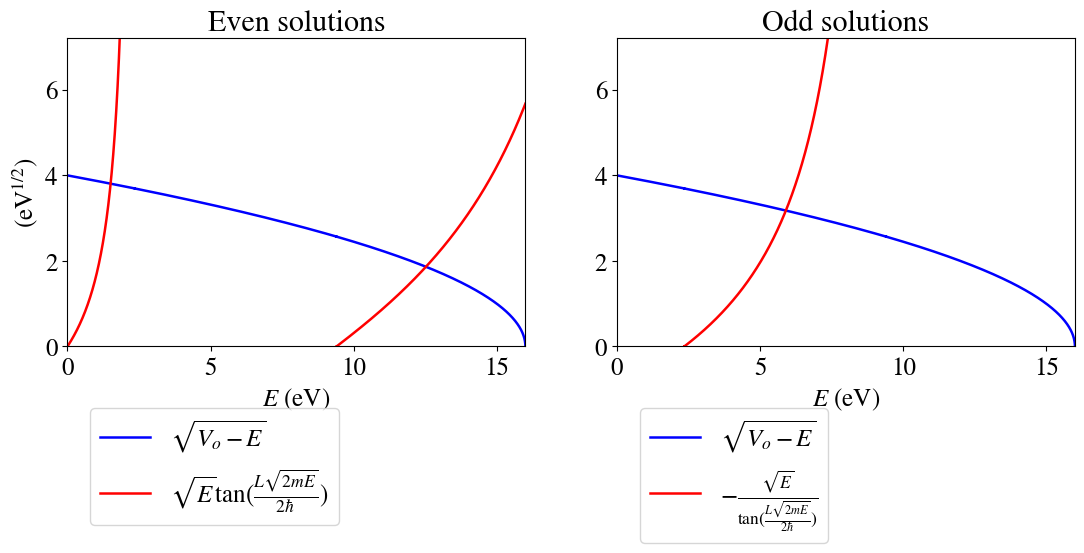

In [8]:
#@title  Plot the solutions for the of $V_o$ and $\textrm{\AA}$, $\text{\r{A}}$ above $\mathring{\text{A}}$ $\text{\AA}$ f"

Vo = Vo_widget.value
L = L_widget.value

hbar = 1.05457180013e-34 # planck's constant divided by 2*pi, in Joules*second
melec = 9.10938356e-31 # mass of an electron in kg
eVtoJ = 1.60217662e-19 # conversion factor from eV to Joules
AngstromtoMeter = 1e-10 # conversion factor from Angstroms to meters
val = np.sqrt(2.0*melec*eVtoJ)*AngstromtoMeter/(2.0*hbar) # prefactor sqrt(2*melec)/(2*hbar), for when L is in angstroms and Vo is in eV

# Generating the graph
plt.rcParams.update({'font.size': 18, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].axis([0.0,Vo,0.0,np.sqrt(Vo)*1.8])
axes[0].set_xlabel(r'$E$ (eV)')
axes[0].set_ylabel(r'(eV$^{1/2}$)')
axes[0].set_title('Even solutions')
axes[1].axis([0.0,Vo,0.0,np.sqrt(Vo)*1.8])
axes[1].set_xlabel(r'$E$ (eV)')
axes[1].set_ylabel(r'')
axes[1].set_title('Odd solutions')
E = np.linspace(0.0, Vo, 10000)
num = int(round((L*np.sqrt(Vo)*val-np.pi/2.0)/np.pi))
# Removing discontinuity points
for n in range(10000):
    for m in range(num+2):
        if abs(E[n]-((2.0*float(m)+1.0)*np.pi/(2.0*L*val))**2)<0.01: E[n] = np.nan
        if abs(E[n]-(float(m)*np.pi/(L*val))**2)<0.01: E[n] = np.nan
# Plotting the curves and setting the labels
axes[0].plot(E, np.sqrt(Vo-E), label=r"$\sqrt{V_o-E}$", color="blue", linewidth=1.8)
axes[0].plot(E, np.sqrt(E)*np.tan(L*np.sqrt(E)*val), label=r"$\sqrt{E}\tan(\frac{L\sqrt{2mE}}{2\hbar})$", color="red", linewidth=1.8)
axes[1].plot(E, np.sqrt(Vo-E), label=r"$\sqrt{V_o-E}$", color="blue", linewidth=1.8)
axes[1].plot(E, -np.sqrt(E)/np.tan(L*np.sqrt(E)*val), label=r"$-\frac{\sqrt{E}}{\tan(\frac{L\sqrt{2mE}}{2\hbar})}$", color="red", linewidth=1.8)
# Chosing the positions of the legends
axes[0].legend(bbox_to_anchor=(0.05, -0.2), loc=2, borderaxespad=0.0)
axes[1].legend(bbox_to_anchor=(0.05, -0.2), loc=2, borderaxespad=0.0)

# Show the plots on the screen once the code reaches this point
plt.show()

In [9]:
from bokeh.plotting import ColumnDataSource, figure, output_file, show
from bokeh.models import Range1d, Tooltip

from bokeh.models import BoxSelectTool

plot = figure(tools="pan,wheel_zoom,box_zoom,reset")

from bokeh.io import output_notebook
# Call once to configure Bokeh to display plots inline in the notebook.
output_notebook()

Loading BokehJS ...

In [10]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
np.seterr(divide='ignore', invalid='ignore')


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [11]:
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [14]:
#@title Plot both sides of the equalities
from bokeh.plotting import figure, output_file, show, ColumnDataSource, save
from bokeh.models import HoverTool, BoxSelectTool, CrosshairTool, Range1d
from bokeh.layouts import row, column
import numpy as np

# Using globally defined Vo and L (from earlier cells) to avoid NameError if widgets are not run.
# If interactive widgets are desired, ensure GYPmtSW6dd6i is run first.
Vo = Vo_widget.value # Original line
L = L_widget.value   # Original line

hbar = 1.05457180013e-34 # planck's constant divided by 2*pi, in Joules*second
melec = 9.10938356e-31 # mass of an electron in kg
eVtoJ = 1.60217662e-19 # conversion factor from eV to Joules
AngstromtoMeter = 1e-10 # conversion factor from Angstroms to meters
val = np.sqrt(2.0*melec*eVtoJ)*AngstromtoMeter/(2.0*hbar) # prefactor sqrt(2*melec)/(2*hbar), for when L is in angstroms and Vo is in eV

E = np.linspace(0.0, Vo, 10000)
LHS = np.array(np.sqrt(Vo-E))
RHS = np.array(np.sqrt(E)*np.tan(L*np.sqrt(E)*val))

RHS2 = -np.sqrt(E)/np.tan(L*np.sqrt(E)*val)

ymax = np.sqrt(Vo)*1.8

for i in RHS:
  if i > ymax:
    RHS[RHS == i] = np.nan

  if i < 0:
    RHS[RHS == i] = np.nan

for i in RHS2:
  if i > ymax:
    RHS2[RHS2 == i] = np.nan

  if i < 0:
    RHS2[RHS2 == i] = np.nan

source = ColumnDataSource(
        data=dict(
            x=E,
            y=LHS,
            y2=RHS,
            y3=RHS2
            #relative_energy=df_all["REL_E"],
            #color = df_all["color"],
            #forcefield = df_all["ForceField"],
            #hbonds = df_all["hbond_count"],
            #struct_index = structureindex
        )
    )

hover = HoverTool(
        tooltips=[
            #("Energy"),
            #("index", "$index"),
            #("H Bonds", "@hbonds"),
            #("Relative E", "@relative_energy"),
            #("Force field", "@forcefield"),
            ("Energy", "$x")
        ]
    )

g = figure(width=500, height=300, tools = "box_zoom,pan, reset")
g.y_range = Range1d(0, np.sqrt(Vo)*1.8)

g.xaxis.axis_label = 'E (eV)'
g.yaxis.axis_label = r'$$\sqrt{V_o - E} \, \, \left(eV^{1/2} \right)$$ '

g.add_tools(hover)
g.title.text = r'$$Even \, Solutions, \, \, \sqrt{V_o - E} =\sqrt{E}\tan\left( \frac{L\sqrt{2mE}}{2\hbar}\right)$$'

g.line(x = 'x', y ='y',  source=source, legend_label="LHS" )
g.line(x = 'x', y ='y2', color = 'red',  source=source, legend_label="RHS" )


g.legend.click_policy = "hide"  # or "mute"


h = figure(width=500, height=300, tools = "box_zoom,pan, reset")
h.y_range = Range1d(0, np.sqrt(Vo)*1.8)

h.xaxis.axis_label = 'E (eV)'
label1 = r'$$\sqrt{V_o-E}$$'
h.yaxis.axis_label = r'$$\sqrt{V_o - E}$$  (eV^{1/2})'
h.title.text = r'$$Odd \, Solutions, \, \,  \sqrt{V_o - E}= -\frac{\sqrt{E}}{\tan \left(\frac{L\sqrt{2mE}}{2\hbar}\right)} $$'


h.add_tools(hover)

h.line(x = 'x', y ='y',  source=source, legend_label ="LHS")
h.line(x = 'x', y ='y3', color = 'red',  source=source, legend_label ="RHS" )

h.legend.click_policy = "hide"  # or "mute"


output_file("StackedEnergies.html")
#output_notebook()

h1=h
g1 = g

layout = column(g1,h1)
show(layout)







The allowed values would then be the values of $E$ in which the two curves cross.
Here are some question to think about:
* **Q1:** How many bound states are possible?
* **Q2:** How many bound states are even and how many are odd?
* **Q3:** Is the ground state described by an even or an odd wavefunction?
* **Q4:** Can you read the allowed values of energy to four significant figures from these graphs?

The allowed values of $E$ can be found by numerically, yielding:

In [ ]:
# @title Numerical Determination of Allowed Energies
print ("The allowed bounded energies are:")
# We want to find the values of E in which f_even and f_odd are zero
f_even = lambda E : np.sqrt(Vo-E)-np.sqrt(E)*np.tan(L*np.sqrt(E)*val)
f_odd = lambda E : np.sqrt(Vo-E)+np.sqrt(E)/np.tan(L*np.sqrt(E)*val)
E_old = 0.0
f_even_old = f_even(0.0)
f_odd_old = f_odd(0.0)
n = 1
E_vals = np.zeros(999)
# Here we loop from E = 0 to E = Vo seeking roots
for E in np.linspace(0.0, Vo, 200000):
    f_even_now = f_even(E)
    # If the difference is zero or if it changes sign then we might have passed through a root
    if f_even_now == 0.0 or f_even_now/f_even_old < 0.0:
        # If the old values of f are not close to zero, this means we didn't pass through a root but
        # through a discontinuity point
        if (abs(f_even_now)<1.0 and abs(f_even_old)<1.0):
            E_vals[n-1] = (E+E_old)/2.0
            print("  State #%3d (Even wavefunction): %9.4f eV, %13.6g J" % (n,E_vals[n-1],E_vals[n-1]*1.60217662e-19))
            n += 1
    f_odd_now = f_odd(E)
    # If the difference is zero or if it changes sign then we might have passed through a root
    if f_odd_now == 0.0 or f_odd_now/f_odd_old < 0.0:
        # If the old values of f are not close to zero, this means we didn't pass through a root but
        # through a discontinuity point
        if (abs(f_odd_now)<1.0 and abs(f_odd_old)<1.0):
            E_vals[n-1] = (E+E_old)/2.0
            print("  State #%3d  (Odd wavefunction): %9.4f eV, %13.6g J" % (n,E_vals[n-1],E_vals[n-1]*1.60217662e-19))
            n += 1
    E_old = E
    f_even_old = f_even_now
    f_odd_old = f_odd_now
nstates = n-1
print ("\nTHERE ARE %3d POSSIBLE BOUNDED ENERGIES" % nstates)

The allowed bounded energies are:
  State #  1 (Even wavefunction):    1.5089 eV,   2.41757e-19 J
  State #  2  (Odd wavefunction):    5.9006 eV,   9.45385e-19 J
  State #  3 (Even wavefunction):   12.5257 eV,   2.00684e-18 J

THERE ARE   3 POSSIBLE BOUNDED ENERGIES


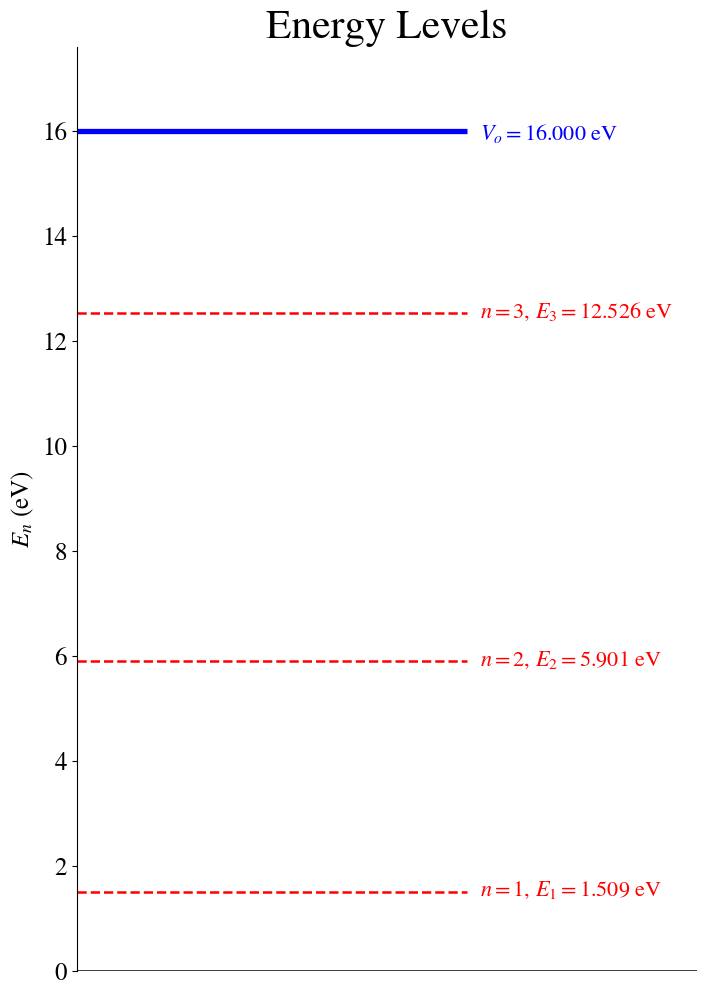

In [ ]:
# @title
# Generating the energy diagram
fig, ax = plt.subplots(figsize=(8,12))
ax.spines['right'].set_color('none')
ax.yaxis.tick_left()
ax.spines['bottom'].set_color('none')
ax.axes.get_xaxis().set_visible(False)
ax.spines['top'].set_color('none')
ax.axis([0.0,10.0,0.0,1.1*Vo])
ax.set_ylabel(r'$E_n$ (eV)')
for n in range(1,nstates+1):
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    ax.text(6.5, E_vals[n-1]-0.005*Vo, str1, fontsize=16, color="red")
    ax.hlines(E_vals[n-1], 0.0, 6.3, linewidth=1.8, linestyle='--', color="red")
str1="$V_o = %.3f$ eV"%(Vo)
ax.text(6.5, Vo-0.01*Vo, str1, fontsize=16, color="blue")
ax.hlines(Vo, 0.0, 6.3, linewidth=3.8, linestyle='-', color="blue")
ax.hlines(0.0, 0.0, 10.3, linewidth=1.8, linestyle='-', color="black")
plt.title("Energy Levels", fontsize=30)
plt.show()



The bound wavefunctions are:
amp
1.7110819108602586
k
0.6293217281508816
amp
1.7110819108602586
amp
1.7110819108602586
k
1.8131744132596788


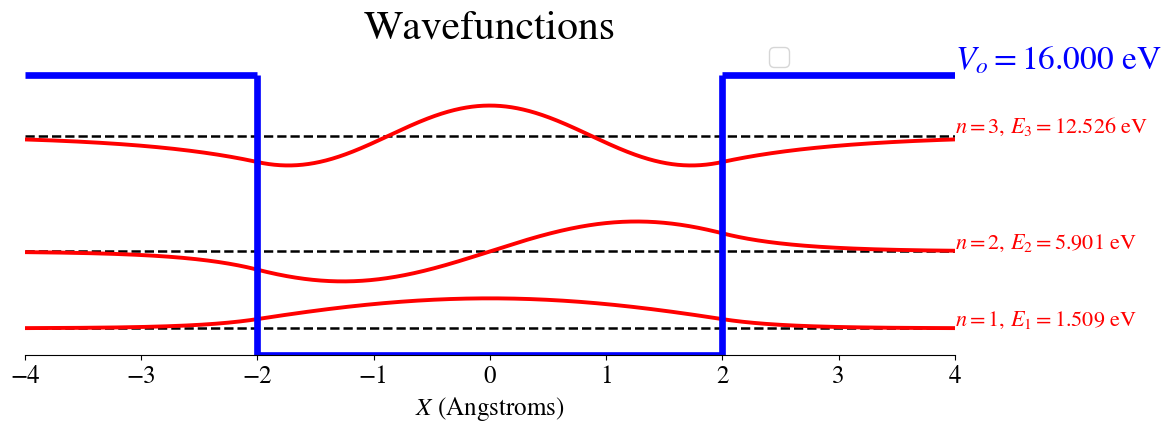

In [ ]:
# @title
print ("\nThe bound wavefunctions are:")
fig, ax = plt.subplots(figsize=(12,4)) #fig, ax = plt.subplots(figsize=(12,9))
ax.spines['right'].set_color('none')
ax.xaxis.tick_bottom()
ax.spines['left'].set_color('none')
ax.axes.get_yaxis().set_visible(False)
ax.spines['top'].set_color('none')
X_lef = np.linspace(-L, -L/2.0, 900,endpoint=True)
X_mid = np.linspace(-L/2.0, L/2.0, 900,endpoint=True)
X_rig = np.linspace(L/2.0, L, 900,endpoint=True)
ax.axis([-L,L,0.0,1.1*Vo])
ax.set_xlabel(r'$X$ (Angstroms)')
str1="$V_o = %.3f$ eV"%(Vo)
ax.text(2.0*L/2.0, 1.02*Vo, str1, fontsize=24, color="blue")
# Defining the maximum amplitude of the wavefunction
if (nstates > 1):
    amp = np.sqrt((E_vals[1]-E_vals[0])/1.5)
else:
    amp = np.sqrt((Vo-E_vals[0])/1.5)
# Plotting the wavefunctions
for n in range(1,nstates+1):
    ax.hlines(E_vals[n-1], -L, L, linewidth=1.8, linestyle='--', color="black")
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    ax.text(2.0*L/2.0, E_vals[n-1]+0.01*Vo, str1, fontsize=16, color="red")
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # Plotting odd wavefunction
    if (n%2==0):
        ax.plot(X_lef,E_vals[n-1]-amp*np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(a0*X_lef), color="red", label="", linewidth=2.8)
        ax.plot(X_mid,E_vals[n-1]+amp*np.sin(k*X_mid), color="red", label="", linewidth=2.8)
        ax.plot(X_rig,E_vals[n-1]+amp*np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(-a0*X_rig), color="red", label="", linewidth=2.8)
        print("amp")
        print(amp)

        #plt.fill_between(X_mid, E_vals[n-1]+amp*np.sin(k*X_mid), alpha=0.2, color='springgreen')
        #plt.fill_between(v, fm4, alpha=0.2, color='deepskyblue')
        #plt.fill_between(v, fm2, alpha=0.1, color='blue')
        #plt.fill_between(v, fm5, alpha=0.1, color='m')
    # Plotting even wavefunction
    else:
        ax.plot(X_lef,E_vals[n-1]+amp*np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(a0*X_lef), color="red", label="", linewidth=2.8)
        ax.plot(X_mid,E_vals[n-1]+amp*np.cos(k*X_mid), color="red", label="", linewidth=2.8)
        ax.plot(X_rig,E_vals[n-1]+amp*np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(-a0*X_rig), color="red", label="", linewidth=2.8)
        print("amp")
        print(amp)
        print("k")
        print(k)

        #ax.plot(X_lef,E_vals[n-1]+amp*np.cos(k*X_lef), color="red", label="", linewidth=2.8)
        #ax.plot(X_rig,E_vals[n-1]+amp*np.cos(k*X_rig), color="red", label="", linewidth=2.8)

        #ax.fill_between(X_mid, E_vals[n-1], E_vals[n-1]+amp*np.cos(k*X_mid), alpha=0.2, color='red')
ax.margins(0.00)
ax.vlines(-L/2.0, 0.0, Vo, linewidth=4.8, color="blue")
ax.vlines(L/2.0, 0.0, Vo, linewidth=4.8, color="blue")
ax.hlines(0.0, -L/2.0, L/2.0, linewidth=4.8, color="blue")
ax.hlines(Vo, -L, -L/2.0, linewidth=4.8, color="blue")
ax.hlines(Vo, L/2.0, L, linewidth=4.8, color="blue")
plt.title('Wavefunctions', fontsize=30)
plt.legend(bbox_to_anchor=(0.8, 1), loc=2, borderaxespad=0.)
plt.show()

In [ ]:
#@title Plots of the even and odd wavefunctions
print(L)
from bokeh.models import Label, Node

x_scale = 1.5
V0_scale = 1.5

X_lef = np.linspace(-x_scale*L, -L/2.0, 900,endpoint=True)
X_mid = np.linspace(-L/2.0, L/2, 900,endpoint=True)
X_rig = np.linspace(L/2.0, x_scale*L, 900,endpoint=True)



j = figure(width=400, height=400)

j.x_range = Range1d(-x_scale*L,x_scale*L)

j.xaxis.axis_label = r'$$X$$ (Angstroms)'
# g.yaxis.axis_label = r'$$\sqrt{E} \, \, \left(eV^{1/2} \right)$$ '

str1="$V_o = %.3f$ eV"%(Vo)
#ax.text(2.05*L/2.0, 1.02*Vo, str1, fontsize=24, color="blue")

#ax.axis([-x_scale*L,x_scale*L,0.0,V0_scale*Vo])
#ax.set_xlabel(r'$X$ (Angstroms)'


x = np.linspace(1,5, 1000)
# add a steps renderer
#j.step([1,  3, 4, 5 ], [4,  0, 4, 4], line_width=2, mode="after")
#
j.step([-2*L,  -L/2, L/2, 2*2 ], [Vo,  0, Vo, Vo], line_width=2, color="black", mode="after")


#citation = Label( x=frame_left, y=frame_bottom, anchor="bottom_left", text="Collected by Luke C. 2016-04-01",
#    padding=10,
#   border_radius=5,
#    border_line_color="black", background_fill_color="white",
#)

citation = Label(x=2*L/2, y=Vo + 0.2, x_units='data', text=r'$$V_o$$',
      background_fill_color='white', background_fill_alpha=1.0)

#p.add_layout(labels)
j.add_layout(citation)

j.yaxis.axis_label = r'$$\psi^2 (1/ Angstrom), \, E_n (eV)$$'


##Trying this...
# Defining the maximum amplitude of the wavefunction
if (nstates > 1):
    amp = np.sqrt((E_vals[1]-E_vals[0])/1.5)
else:
    amp = np.sqrt((Vo-E_vals[0])/1.5)

for n in range(1,nstates+1):
    #ax.hlines(E_vals[n-1], -L, L, linewidth=1.8, linestyle='--', color="black")
    j.step([-2*L,  2*L ], [E_vals[n-1], E_vals[n-1]], line_width=2, color="red", mode="after")
    j_int = str(n)
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    #note = Label(x=-L/2, y=E_vals[n-1], x_units="data", text="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1] ))
    note = Label(x=-2*L, y=E_vals[n-1], x_units="data", text="n = "+str(n)+r", $$E_$$"+str(n)+r" = %.3f eV"%(E_vals[n-1] ))
    note2 = Label(x=-2*L, y=E_vals[n-1], x_units="data", text="n = "+str(n)+r", $$E_{$$"+str(n)+r"} = %.3f eV"%(E_vals[n-1] ))
    j.add_layout(note2)


    #ax.text(2.0*L/2.0, E_vals[n-1]+0.01*Vo, str1, fontsize=16, color="red")
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # Plotting odd probability densities
    if (n%2==0):
        Y_lef = E_vals[n-1]-amp*(np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(a0*X_lef))
        #j.line(X_lef,Y_lef, color="red", label="", linewidth=2.8)
        j.line(X_lef,Y_lef, color="red")
        #ax.fill_between(X_lef, E_vals[n-1], Y_lef, color="#3dbb2a")
        #j.plot(X_mid,E_vals[n-1]+amp*(np.sin(k*X_mid))**2, color="red", label="", linewidth=2.8)
        j.line(X_mid,E_vals[n-1]+amp*(np.sin(k*X_mid)))
        Y_rig = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(-a0*X_rig))
        #j.line(X_rig,Y_rig, color="red", label="", linewidth=2.8)
        j.line(X_rig,Y_rig, color="red")
        #ax.fill_between(X_rig, E_vals[n-1], Y_rig, color="#3dbb2a")



    # Plotting even probability densities
    else:
        Y_lef = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(a0*X_lef))
        #j.line(X_lef,Y_lef, color="red", label="", linewidth=2.8)
        j.line(X_lef,Y_lef, color="red")
        #ax.fill_between(X_lef, E_vals[n-1], Y_lef, alpha=0.2, color='lightgreen')
        #j.line(X_mid,E_vals[n-1]+amp*(np.cos(k*X_mid))**2, color="red", label="", linewidth=2.8)
        j.line(X_mid,E_vals[n-1]+amp*(np.cos(k*X_mid)))
        Y_rig = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(-a0*X_rig))
        #j.line(X_rig,Y_rig, color="red", label="", linewidth=2.8)
        j.line(X_rig,Y_rig, color="red")

        j.legend.click_policy = "hide"  # or "mute"




        #ax.fill_between(X_rig, E_vals[n-1], Y_rig, alpha=0.2, color='lightgreen')

show(j)

4.0


If we compare these results with those of a particle in a box of same size but with infinite potential, we conclude that in the finite box, the levels are shifted to lower energies.
More strikingly is the observation that the wavefunctions and the probability densities have non-zero values outside the box limits.

Classically, the particle cannot be found outside the box because the available energy is lower than the potential wall ($E < V_o$). However, for the particle in the finite box the wavefunction is nonzero outside the box, which means that there is a possibility of finding the particle outside the box. This is a pure quantum effect called the **tunneling effect**.

The tunneling probability correspond to the area outside the box that has non-zero values of probability density. In the graphicaly representation, those areas are shaded in green. The integration of those areas provide the probability that the particle will tunnel outside the classically allowed region.

$$ \large{\frac{\int^{\frac{-L}{2}}_{-\infty} |\psi(x)|^2\ dx +\int^{+\infty}_{\frac{L}{2}} |\psi(x)|^2\ dx }{\int_{-\infty}^{+\infty} |\psi(x)|^2\ dx }}$$
where the denominator is 1 for a normalized wavefunction.

This integral can be solved analytically (for the even and for the odd solutions). The tunneling probability for each state is:

In [ ]:
print ("\nThe tunneling probabilities are:")
for n in range(1,nstates+1):
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # For odd solution
    if (n%2==0):
        C = 1.0
        D = np.exp(a0*L/2.0)*np.sin(k*L/2.0)*C
        prob = D*D*2.0*k*np.exp(-a0*L)/(B*B*a0*(k*L-np.sin(k*L))+D*D*2.0*k*np.exp(-a0*L))
    # For even solution
    else:
        B = 1.0
        D = np.exp(a0*L/2.0)*np.cos(k*L/2.0)*B
        prob = D*D*2.0*k*np.exp(-a0*L)/(B*B*a0*(k*L+np.sin(k*L))+D*D*2.0*k*np.exp(-a0*L))
    print("  State #%3d tunneling probability = %5.2f%%" % (n,100*prob))


The tunneling probabilities are:
  State #  1 tunneling probability =  1.92%
  State #  2 tunneling probability =  8.66%
  State #  3 tunneling probability = 26.90%


In [ ]:
#@title Plots of the Well and the Wavefunctions Sqaured
from bokeh.models import Label, Node

x_scale = 1.5
V0_scale = 1.5

X_lef = np.linspace(-x_scale*L, -L/2.0, 900,endpoint=True)
X_mid = np.linspace(-L/2.0, L/2, 900,endpoint=True)
X_rig = np.linspace(L/2.0, x_scale*L, 900,endpoint=True)



j = figure(width=400, height=400)

j.x_range = Range1d(-x_scale*L,x_scale*L)

j.xaxis.axis_label = r'$$X$$ (Angstroms)'
# g.yaxis.axis_label = r'$$\sqrt{E} \, \, \left(eV^{1/2} \right)$$ '

str1="$V_o = %.3f$ eV"%(Vo)
#ax.text(2.05*L/2.0, 1.02*Vo, str1, fontsize=24, color="blue")

#ax.axis([-x_scale*L,x_scale*L,0.0,V0_scale*Vo])
#ax.set_xlabel(r'$X$ (Angstroms)'


x = np.linspace(1,5, 1000)
# add a steps renderer
#j.step([1,  3, 4, 5 ], [4,  0, 4, 4], line_width=2, mode="after")
#
j.step([-2*L,  -L/2, L/2, 2*2 ], [Vo,  0, Vo, Vo], line_width=2, color="black", mode="after")


#citation = Label( x=frame_left, y=frame_bottom, anchor="bottom_left", text="Collected by Luke C. 2016-04-01",
#    padding=10,
#   border_radius=5,
#    border_line_color="black", background_fill_color="white",
#)

citation = Label(x=2*L/2, y=Vo + 0.2, x_units='data', text=r'$$V_o$$',
      background_fill_color='white', background_fill_alpha=1.0)

#p.add_layout(labels)
j.add_layout(citation)

j.yaxis.axis_label = r'$$\psi^2 (1/ \mathring{A}), \, E_n (eV)$$'


for n in range(1,nstates+1):
    #ax.hlines(E_vals[n-1], -L, L, linewidth=1.8, linestyle='--', color="black")
    j.step([-2*L,  2*L ], [E_vals[n-1], E_vals[n-1]], line_width=2, color="red", mode="after")
    j_int = str(n)
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    #note = Label(x=-L/2, y=E_vals[n-1], x_units="data", text="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1] ))
    note = Label(x=-2*L, y=E_vals[n-1], x_units="data", text="n = "+str(n)+r", $$E_$$"+str(n)+r" = %.3f eV"%(E_vals[n-1] ))
    note2 = Label(x=-2*L, y=E_vals[n-1], x_units="data", text="n = "+str(n)+r", $$E_{$$"+str(n)+r"} = %.3f eV"%(E_vals[n-1] ))
    j.add_layout(note2)


    #ax.text(2.0*L/2.0, E_vals[n-1]+0.01*Vo, str1, fontsize=16, color="red")
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # Plotting odd probability densities
    if (n%2==0):
        Y_lef = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(a0*X_lef))**2
        #j.line(X_lef,Y_lef, color="red", label="", linewidth=2.8)
        j.line(X_lef,Y_lef, color="red")
        #ax.fill_between(X_lef, E_vals[n-1], Y_lef, color="#3dbb2a")
        #j.plot(X_mid,E_vals[n-1]+amp*(np.sin(k*X_mid))**2, color="red", label="", linewidth=2.8)
        j.line(X_mid,E_vals[n-1]+amp*(np.sin(k*X_mid))**2)
        Y_rig = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(-a0*X_rig))**2
        #j.line(X_rig,Y_rig, color="red", label="", linewidth=2.8)
        j.line(X_rig,Y_rig, color="red")
        #ax.fill_between(X_rig, E_vals[n-1], Y_rig, color="#3dbb2a")
        j.varea(x=X_rig,
          y1=Y_rig,
          y2=E_vals[n-1], color="red", alpha=0.2)
        j.varea(x=X_lef,
          y1=Y_lef,
          y2=E_vals[n-1], color="red", alpha=0.2)


    # Plotting even probability densities
    else:
        Y_lef = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(a0*X_lef))**2
        #j.line(X_lef,Y_lef, color="red", label="", linewidth=2.8)
        j.line(X_lef,Y_lef, color="red")
        #ax.fill_between(X_lef, E_vals[n-1], Y_lef, alpha=0.2, color='lightgreen')
        #j.line(X_mid,E_vals[n-1]+amp*(np.cos(k*X_mid))**2, color="red", label="", linewidth=2.8)
        j.line(X_mid,E_vals[n-1]+amp*(np.cos(k*X_mid))**2)
        Y_rig = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(-a0*X_rig))**2
        #j.line(X_rig,Y_rig, color="red", label="", linewidth=2.8)
        j.line(X_rig,Y_rig, color="red")
        j.varea(x=X_rig,
          y1=Y_rig,
          y2=E_vals[n-1], color="red", alpha=0.2)
        j.varea(x=X_lef,
          y1=Y_lef,
          y2=E_vals[n-1], color="red", alpha=0.2)



        #ax.fill_between(X_rig, E_vals[n-1], Y_rig, alpha=0.2, color='lightgreen')

show(j)

In [ ]:
import os

# Check if the file exists before attempting to remove it
if os.path.exists('downloaded.zip'):
    os.remove('downloaded.zip')
    print("Successfully removed 'downloaded.zip'.")
else:
    print("'downloaded.zip' not found.")

'downloaded.zip' not found.


In [ ]:
from bokeh.plotting import figure, output_file, show, ColumnDataSource, save
from bokeh.models import HoverTool, BoxSelectTool, CrosshairTool, Range1d, FixedTicker, Label, TeX
from bokeh.layouts import row
import numpy as np
from IPython.display import HTML

# Hardcoding values for Vo and L as requested
Vo = 6
L = 4

x_scale = 1.0
V0_scale = 1.6
LabelAboveVo = 1.1

labelfontsize = "14pt"

y_lowerlim = -1

j = figure(width=600, height=400)

j.x_range = Range1d(-x_scale*L,x_scale*L)
j.y_range = Range1d(y_lowerlim,Vo*V0_scale)

j.title.text = r"$$\text{A Square Well of Depth }V_o$$"
j.title.text = f"A Square Well of Depth {Vo} eV and width of {L} Angstroms"
j.title.text_font_size = '14pt'

# Plot a line...
j.step([-2*L,  -L/2, L/2, 2*2 ], [Vo,  0, Vo, Vo], line_width=2, color="black", mode="after")

# Shading the potential barriers
j.varea(x=np.linspace(j.x_range.start, -L/2, 100), y1=y_lowerlim, y2=Vo, color='lightblue', alpha=0.5)
j.varea(x=np.linspace(-L/2, L/2, 100), y1=y_lowerlim, y2=0, color='lightblue', alpha=0.5)
j.varea(x=np.linspace(L/2, j.x_range.end, 100), y1=y_lowerlim, y2=Vo, color='lightblue', alpha=0.5)

# Add vertical dotted lines at x = -L/2 and x = L/2
j.line(x=[-L/2, -L/2], y=[0, Vo*V0_scale], line_dash='dotted', line_color='grey', line_width=2)
j.line(x=[L/2, L/2], y=[0, Vo*V0_scale], line_dash='dotted', line_color='grey', line_width=2)

# Add axis labels
j.yaxis.axis_label = r'$$Energy$$'
j.yaxis.axis_label_text_font_size = labelfontsize

j.xaxis.axis_label = r'$$x(\mathring{\text{A}})$$'
j.xaxis.axis_label_text_font_size = labelfontsize


# Set custom x-axis ticks
j.xaxis.ticker = FixedTicker(ticks=[-L/2, 0, L/2])
j.xaxis.major_label_overrides = {
    -L/2: r'$$-L/2$$',
    0: r'$$0$$',
    L/2: r'$$L/2$$'
}
j.xaxis.major_label_text_font_size = labelfontsize

# Set custom y-axis ticks and labels for 0 and Vo, and hide others
j.yaxis.ticker = FixedTicker(ticks=[0, Vo]) # Example major ticks within the range
j.yaxis.major_label_overrides = {
    0: r'$$0$$',
    Vo: r'$$V_o$$'
}
j.yaxis.major_label_text_font_size = labelfontsize

# # Add Text box labels for the three different regions,
# left (L),
# middle (M), and
# right (R)

strL=r"$$V = V_o$$"
strM=r"$$V = 0$$"
strR=r"$$V = V_o$$"

# add a Labels for the potential in each region.
Vo_label_L  = Label(text=strL,
                    x = -3,
                    y=LabelAboveVo*Vo,
                    x_units='data',
                    y_units='data',
                    text_font_size='12pt',
                    text_color='blue',
                    text_align='center')

Vo_label_M  = Label(text=strM,
                    x = 0,
                    y=LabelAboveVo*Vo,
                    x_units='data',
                    y_units='data',
                    text_font_size='12pt',
                    text_color='blue',
                    text_align='center')

Vo_label_R  = Label(text=strR,
                    x = 3,
                    y=LabelAboveVo*Vo,
                    x_units='data',
                    y_units='data',
                    text_font_size='12pt',
                    text_color='blue',
                    text_align='center')

j.add_layout(Vo_label_L)
j.add_layout(Vo_label_M)
j.add_layout(Vo_label_R)


# Output to an HTML file
output_file("square_well_plot_bokeh.html")
#save(j)

#show(row(j))
show(j)

In [ ]:
from bokeh.plotting import figure, output_file, show, ColumnDataSource, save
from bokeh.models import HoverTool, BoxSelectTool, CrosshairTool, Range1d, FixedTicker, Label, TeX
from bokeh.layouts import row
import numpy as np
from IPython.display import HTML

# Hardcoding values for Vo and L as requested
Vo = 6
L = 4

x_scale = 1.0
V0_scale = 1.6
LabelAboveVo = 1.1

labelfontsize = "14pt"

y_lowerlim = -1

j = figure(width=600, height=400)

j.x_range = Range1d(-x_scale*L,x_scale*L)
j.y_range = Range1d(y_lowerlim,Vo*V0_scale)

j.title.text = r"$$\text{A Square Well of Depth }V_o$$"
j.title.text_font_size = '14pt'

# Plot a line...
j.step([-2*L,  -L/2, L/2, 2*2 ], [Vo,  0, Vo, Vo], line_width=2, color="black", mode="after")

# Shading the potential barriers
j.varea(x=np.linspace(j.x_range.start, -L/2, 100), y1=y_lowerlim, y2=Vo, color='lightblue', alpha=0.5)
j.varea(x=np.linspace(-L/2, L/2, 100), y1=y_lowerlim, y2=0, color='lightblue', alpha=0.5)
j.varea(x=np.linspace(L/2, j.x_range.end, 100), y1=y_lowerlim, y2=Vo, color='lightblue', alpha=0.5)

# Add vertical dotted lines at x = -L/2 and x = L/2
j.line(x=[-L/2, -L/2], y=[0, Vo*V0_scale], line_dash='dotted', line_color='grey', line_width=2)
j.line(x=[L/2, L/2], y=[0, Vo*V0_scale], line_dash='dotted', line_color='grey', line_width=2)

# Add axis labels
j.yaxis.axis_label = r'$$Energy$$'
j.yaxis.axis_label_text_font_size = labelfontsize

j.xaxis.axis_label = r'$$x$$ (Angstroms)'
j.xaxis.axis_label_text_font_size = labelfontsize


# Set custom x-axis ticks
j.xaxis.ticker = FixedTicker(ticks=[-L/2, 0, L/2])
j.xaxis.major_label_overrides = {
    -L/2: r'$$-L/2$$',
    0: r'$$0$$',
    L/2: r'$$L/2$$'
}
j.xaxis.major_label_text_font_size = labelfontsize

# Set custom y-axis ticks and labels for 0 and Vo, and hide others
j.yaxis.ticker = FixedTicker(ticks=[0, Vo]) # Example major ticks within the range
j.yaxis.major_label_overrides = {
    0: r'$$0$$',
    Vo: r'$$V_o$$'
}
j.yaxis.major_label_text_font_size = labelfontsize

# # Add Text box labels for the three different regions,
# left (L),
# middle (M), and
# right (R)

strL=r"$$V = V_o$$"
strM=r"$$V = 0$$"
strR=r"$$V = V_o$$"

# add a Labels for the potential in each region.
Vo_label_L  = Label(text=strL,
                    x = -3,
                    y=LabelAboveVo*Vo,
                    x_units='data',
                    y_units='data',
                    text_font_size='12pt',
                    text_color='blue',
                    text_align='center')

Vo_label_M  = Label(text=strM,
                    x = 0,
                    y=LabelAboveVo*Vo,
                    x_units='data',
                    y_units='data',
                    text_font_size='12pt',
                    text_color='blue',
                    text_align='center')

Vo_label_R  = Label(text=strR,
                    x = 3,
                    y=LabelAboveVo*Vo,
                    x_units='data',
                    y_units='data',
                    text_font_size='12pt',
                    text_color='blue',
                    text_align='center')

j.add_layout(Vo_label_L)
j.add_layout(Vo_label_M)
j.add_layout(Vo_label_R)

# Output to an HTML file
output_file("square_well_plot_bokeh.html")
#save(j)

show(j)


In [ ]:
from IPython.display import HTML


from IPython.display import HTML

In [ ]:
from IPython.display import IFrame, HTML
import html

with open('square_well_plot_bokeh.html', 'r') as f:
    content = f.read()

# srcdoc embeds the HTML directly, no file path needed
escaped = html.escape(content)
display(HTML(f'<iframe srcdoc="{escaped}" width="800" height="600"></iframe>'))

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [ ]:
# Display the HTML file in an iframe
display(IFrame(src='square_well_plot.html', width=700, height=500))

In [ ]:
## latex was good here.

from IPython.display import IFrame, HTML
import html

with open('square_well_plot_bokeh.html', 'r') as f:
    content = f.read()

# srcdoc embeds the HTML directly, no file path needed
escaped = html.escape(content)
display(HTML(f'<iframe srcdoc="{escaped}" width="600" height="600"></iframe>'))